<a href="https://colab.research.google.com/github/ntlcs/fiap-pos-ia-tech-challenge-fase-1-extra-visao-computacional/blob/main/01_Visao_Computacional_Pneumonia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🫁 Tech Challenge – Fase 1 | Projeto Extra

## Detecção de Pneumonia em Radiografias Torácicas utilizando Deep Learning e Visão Computacional

**Pós-Graduação em Inteligência Artificial – FIAP**

**Autora:** Natalia da Costa Silva

---

## Objetivo

Desenvolver uma solução de Visão Computacional capaz de classificar radiografias torácicas em duas categorias:

- `NORMAL`: radiografia sem indicativo de pneumonia;
- `PNEUMONIA`: radiografia com indicativo de pneumonia.

Este projeto corresponde à atividade complementar de Visão Computacional do Tech Challenge – Fase 1.

In [1]:
from pathlib import Path
from collections import Counter
import hashlib
import os

import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from PIL import Image, UnidentifiedImageError

In [2]:
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# 1. Carregamento do Dataset

O dataset utilizado contém radiografias torácicas organizadas em classes que representam exames normais e exames com pneumonia.

Nesta etapa, o conjunto de dados é baixado e sua estrutura de diretórios é inspecionada antes de qualquer transformação.

In [3]:
dataset_path = Path(
    kagglehub.dataset_download(
        "paultimothymooney/chest-xray-pneumonia"
    )
)

print(f"Dataset baixado em: {dataset_path}")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset baixado em: /kaggle/input/chest-xray-pneumonia


In [4]:
pastas_chest_xray = [
    pasta
    for pasta in dataset_path.rglob("chest_xray")
    if pasta.is_dir()
]

if len(pastas_chest_xray) == 0:
    raise FileNotFoundError(
        "A pasta 'chest_xray' não foi encontrada no dataset."
    )

data_dir = pastas_chest_xray[0]

print(f"Pasta principal encontrada: {data_dir}")

Pasta principal encontrada: /kaggle/input/chest-xray-pneumonia/chest_xray


In [5]:
for caminho in sorted(data_dir.rglob("*")):
    if caminho.is_dir():
        nivel = len(caminho.relative_to(data_dir).parts)
        identacao = "    " * nivel
        print(f"{identacao}📁 {caminho.name}")

    📁 __MACOSX
        📁 chest_xray
            📁 test
                📁 NORMAL
                📁 PNEUMONIA
            📁 train
                📁 NORMAL
                📁 PNEUMONIA
            📁 val
                📁 NORMAL
                📁 PNEUMONIA
    📁 chest_xray
        📁 test
            📁 NORMAL
            📁 PNEUMONIA
        📁 train
            📁 NORMAL
            📁 PNEUMONIA
        📁 val
            📁 NORMAL
            📁 PNEUMONIA
    📁 test
        📁 NORMAL
        📁 PNEUMONIA
    📁 train
        📁 NORMAL
        📁 PNEUMONIA
    📁 val
        📁 NORMAL
        📁 PNEUMONIA


# 2. Construção do Catálogo das Imagens

Para analisar o conjunto de dados de forma estruturada, será criado um DataFrame contendo:

- caminho da imagem;
- conjunto ao qual pertence;
- classe;
- extensão do arquivo;
- largura e altura;
- modo de cor;
- tamanho do arquivo.

In [6]:
extensoes_validas = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp"
}

registros = []
arquivos_corrompidos = []

for split in ["train", "val", "test"]:
    split_dir = data_dir / split

    for classe in ["NORMAL", "PNEUMONIA"]:
        classe_dir = split_dir / classe

        if not classe_dir.exists():
            print(f"Pasta não encontrada: {classe_dir}")
            continue

        for arquivo in classe_dir.iterdir():
            if arquivo.suffix.lower() not in extensoes_validas:
                continue

            try:
                with Image.open(arquivo) as imagem:
                    largura, altura = imagem.size

                    registros.append({
                        "arquivo": arquivo.name,
                        "caminho": str(arquivo),
                        "split": split,
                        "classe": classe,
                        "extensao": arquivo.suffix.lower(),
                        "largura": largura,
                        "altura": altura,
                        "modo_cor": imagem.mode,
                        "tamanho_kb": arquivo.stat().st_size / 1024
                    })

            except (
                UnidentifiedImageError,
                OSError
            ) as erro:
                arquivos_corrompidos.append({
                    "arquivo": str(arquivo),
                    "erro": str(erro)
                })

df_imagens = pd.DataFrame(registros)

print(f"Total de imagens válidas: {len(df_imagens)}")
print(f"Total de arquivos corrompidos: {len(arquivos_corrompidos)}")

display(df_imagens.head())

Total de imagens válidas: 5856
Total de arquivos corrompidos: 0


,arquivo,caminho,split,classe,extensao,largura,altura,modo_cor,tamanho_kb
0,NORMAL2-IM-0771-0001.jpeg,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,NORMAL,.jpeg,1336,1128,L,148.803711
1,NORMAL2-IM-1294-0001-0002.jpeg,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,NORMAL,.jpeg,1400,1260,L,527.088867
2,IM-0675-0001.jpeg,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,NORMAL,.jpeg,1218,1032,L,341.994141
3,NORMAL2-IM-1169-0001.jpeg,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,NORMAL,.jpeg,1782,1433,L,614.438477
4,IM-0421-0001.jpeg,/kaggle/input/chest-xray-pneumonia/chest_xray/...,train,NORMAL,.jpeg,1574,1129,L,451.316406


In [7]:
df_imagens.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   arquivo     5856 non-null   object 
 1   caminho     5856 non-null   object 
 2   split       5856 non-null   object 
 3   classe      5856 non-null   object 
 4   extensao    5856 non-null   object 
 5   largura     5856 non-null   int64  
 6   altura      5856 non-null   int64  
 7   modo_cor    5856 non-null   object 
 8   tamanho_kb  5856 non-null   float64
dtypes: float64(1), int64(2), object(6)
memory usage: 411.9+ KB


In [8]:
display(
    df_imagens.describe(
        include="all"
    ).transpose()
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
arquivo,5856,5856,person85_bacteria_424.jpeg,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
caminho,5856,5856,/kaggle/input/chest-xray-pneumonia/chest_xray/...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
split,5856,3,train,5216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
classe,5856,2,PNEUMONIA,4273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
extensao,5856,1,.jpeg,5856,NaN,NaN,NaN,NaN,NaN,NaN,NaN
largura,5856.0,NaN,NaN,NaN,1327.880806,363.500922,384.0,1056.0,1281.0,1560.0,2916.0
altura,5856.0,NaN,NaN,NaN,970.689037,383.392117,127.0,688.0,888.0,1187.0,2713.0
modo_cor,5856,2,L,5573,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tamanho_kb,5856.0,NaN,NaN,NaN,206.199238,258.600371,5.313477,54.750977,93.592773,230.484619,2357.755859


In [9]:
df_imagens.isna().sum()

,0
arquivo,0
caminho,0
split,0
classe,0
extensao,0
largura,0
altura,0
modo_cor,0
tamanho_kb,0


In [10]:
df_imagens["extensao"].value_counts()

,count
extensao,
.jpeg,5856


In [11]:
df_imagens["modo_cor"].value_counts()

,count
modo_cor,
L,5573
RGB,283


# 3. Distribuição das Imagens

A distribuição das imagens será analisada por classe e por conjunto de dados, permitindo identificar:

- desbalanceamento entre `NORMAL` e `PNEUMONIA`;
- diferenças de tamanho entre treino, validação e teste;
- possíveis riscos para o processo de avaliação.

In [12]:
distribuicao = pd.crosstab(
    df_imagens["split"],
    df_imagens["classe"],
    margins=True,
    margins_name="Total"
)

display(distribuicao)

classe,NORMAL,PNEUMONIA,Total
split,,,
test,234,390,624
train,1341,3875,5216
val,8,8,16
Total,1583,4273,5856


In [13]:
distribuicao_percentual = pd.crosstab(
    df_imagens["split"],
    df_imagens["classe"],
    normalize="index"
).mul(100)

display(distribuicao_percentual.round(2))

classe,NORMAL,PNEUMONIA
split,,
test,37.50,62.50
train,25.71,74.29
val,50.00,50.00


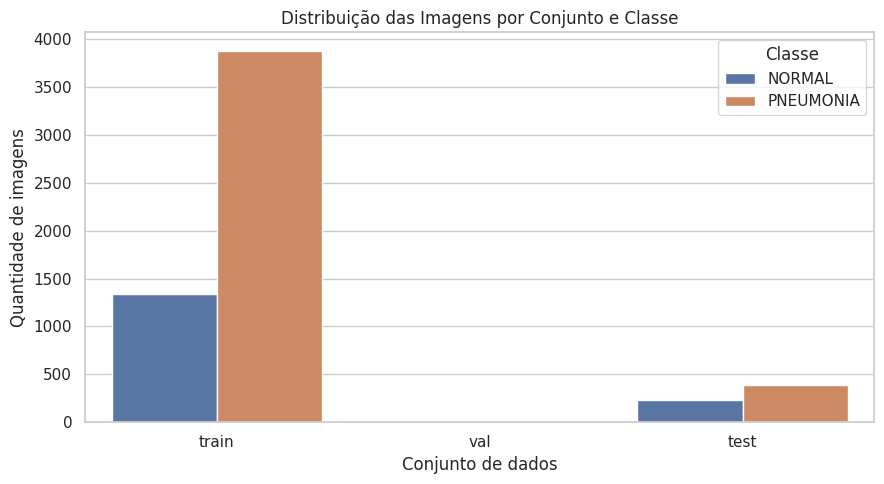

In [14]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_imagens,
    x="split",
    hue="classe",
    order=["train", "val", "test"]
)

plt.title("Distribuição das Imagens por Conjunto e Classe")
plt.xlabel("Conjunto de dados")
plt.ylabel("Quantidade de imagens")
plt.legend(title="Classe")
plt.tight_layout()
plt.show()

### Interpretação

A distribuição das imagens evidencia diferenças na quantidade de exemplos entre as classes `NORMAL` e `PNEUMONIA`, além de variações relevantes entre os conjuntos de treino, validação e teste.

Esse comportamento deve ser considerado durante a modelagem, pois um modelo treinado em dados desbalanceados pode favorecer a classe mais frequente. Por esse motivo, métricas como Precision, Recall, F1-score e ROC-AUC serão analisadas em conjunto com a Accuracy.

Também será necessário avaliar se o conjunto de validação possui quantidade suficiente de imagens para produzir uma estimativa confiável durante o treinamento.

# 4. Inspeção Visual das Radiografias

A inspeção visual permite observar diferenças de contraste, enquadramento, resolução, presença de marcações e possíveis padrões associados às classes.

Essa análise também auxilia na identificação de artefatos que poderiam ser aprendidos incorretamente pelo modelo.

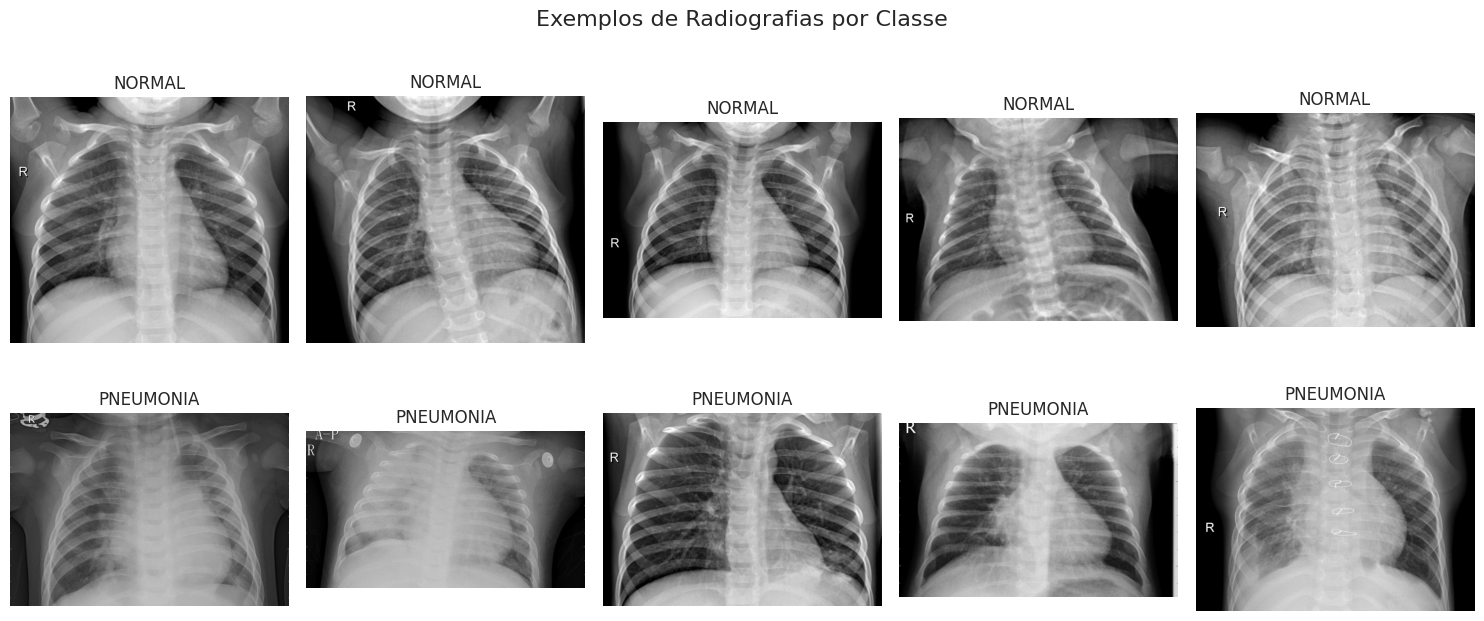

In [15]:
amostras_por_classe = 5

fig, axes = plt.subplots(
    2,
    amostras_por_classe,
    figsize=(15, 7)
)

for linha, classe in enumerate(
    ["NORMAL", "PNEUMONIA"]
):
    amostras = (
        df_imagens[
            (df_imagens["split"] == "train")
            & (df_imagens["classe"] == classe)
        ]
        .sample(
            n=amostras_por_classe,
            random_state=42
        )
    )

    for coluna, (_, registro) in enumerate(
        amostras.iterrows()
    ):
        imagem = Image.open(
            registro["caminho"]
        ).convert("L")

        axes[linha, coluna].imshow(
            imagem,
            cmap="gray"
        )

        axes[linha, coluna].set_title(
            classe
        )

        axes[linha, coluna].axis("off")

plt.suptitle(
    "Exemplos de Radiografias por Classe",
    fontsize=16
)

plt.tight_layout()
plt.show()